In [18]:
import os
import shutil
import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

In [19]:
from pathlib import Path

# Original extracted dataset location
SOURCE_DIR = Path(r"D:\Advanced data science Lab\Assignment_4\archive (6)\training_image")

# Main assignment directory
PROJECT_DIR = Path(r"D:\Advanced data science Lab\Assignment_4")

# New YOLO dataset directory
DATASET_DIR = PROJECT_DIR / "yolo_dataset"

print("Source directory:")
print(SOURCE_DIR)

print("\nDataset directory:")
print(DATASET_DIR)

print("\nSource exists:", SOURCE_DIR.exists())

Source directory:
D:\Advanced data science Lab\Assignment_4\archive (6)\training_image

Dataset directory:
D:\Advanced data science Lab\Assignment_4\yolo_dataset

Source exists: True


In [20]:
files = list(SOURCE_DIR.rglob("*"))

print("Total files:", len(files))

print("\nFirst 30 files:")

for file in files[:30]:
    print(file)

Total files: 1117

First 30 files:
D:\Advanced data science Lab\Assignment_4\archive (6)\training_image\100Ambulance.jpg
D:\Advanced data science Lab\Assignment_4\archive (6)\training_image\100Ambulance.txt
D:\Advanced data science Lab\Assignment_4\archive (6)\training_image\100car.jpg
D:\Advanced data science Lab\Assignment_4\archive (6)\training_image\100car.txt
D:\Advanced data science Lab\Assignment_4\archive (6)\training_image\100Truck.jpg
D:\Advanced data science Lab\Assignment_4\archive (6)\training_image\100Truck.txt
D:\Advanced data science Lab\Assignment_4\archive (6)\training_image\101Ambulance.jpg
D:\Advanced data science Lab\Assignment_4\archive (6)\training_image\101Ambulance.txt
D:\Advanced data science Lab\Assignment_4\archive (6)\training_image\101car.jpg
D:\Advanced data science Lab\Assignment_4\archive (6)\training_image\101car.txt
D:\Advanced data science Lab\Assignment_4\archive (6)\training_image\101Truck.jpg
D:\Advanced data science Lab\Assignment_4\archive (6)\t

In [21]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

image_files = [
    p for p in SOURCE_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

label_files = [
    p for p in SOURCE_DIR.rglob("*.txt")
    if p.is_file()
]

print("Number of images :", len(image_files))
print("Number of labels :", len(label_files))

Number of images : 556
Number of labels : 559


In [22]:
label_map = {p.stem: p for p in label_files}

paired_images = []
missing_labels = []

for img in image_files:
    if img.stem in label_map:
        paired_images.append(img)
    else:
        missing_labels.append(img)

print("Images with labels :", len(paired_images))
print("Images without labels :", len(missing_labels))

if missing_labels:
    print("\nFirst missing labels:")
    for img in missing_labels[:10]:
        print(img)

Images with labels : 556
Images without labels : 0


In [23]:
CLASS_NAMES = [
    "Ambulance",
    "Bus",
    "Car",
    "Truck"
]

NUM_CLASSES = len(CLASS_NAMES)

print("Classes:")
for i, name in enumerate(CLASS_NAMES):
    print(i, "→", name)

Classes:
0 → Ambulance
1 → Bus
2 → Car
3 → Truck


In [24]:
for img_path in paired_images[:5]:
    label_path = label_map[img_path.stem]
    
    print("\nImage:", img_path.name)
    print("Label:", label_path.name)
    
    with open(label_path, "r") as f:
        print(f.read()[:500])


Image: 100Ambulance.jpg
Label: 100Ambulance.txt


Image: 100car.jpg
Label: 100car.txt
2 0.392692 0.542725 0.659231 0.602771


Image: 100Truck.jpg
Label: 100Truck.txt
3 0.526367 0.532986 0.712891 0.736111


Image: 101Ambulance.jpg
Label: 101Ambulance.txt
0 0.511000 0.492000 0.818000 0.776000


Image: 101car.jpg
Label: 101car.txt
2 0.561667 0.505000 0.420000 0.580000



In [25]:
invalid_annotations = []

for label_path in label_files:
    with open(label_path, "r") as f:
        lines = f.readlines()

    for line_no, line in enumerate(lines, start=1):
        line = line.strip()

        if not line:
            continue

        parts = line.split()

        if len(parts) != 5:
            invalid_annotations.append(
                (label_path.name, line_no, line)
            )
            continue

        try:
            class_id = int(float(parts[0]))
            coords = [float(x) for x in parts[1:]]
            
            if class_id < 0 or class_id >= NUM_CLASSES:
                invalid_annotations.append(
                    (label_path.name, line_no, line)
                )
            
            if not all(0 <= x <= 1 for x in coords):
                invalid_annotations.append(
                    (label_path.name, line_no, line)
                )

        except ValueError:
            invalid_annotations.append(
                (label_path.name, line_no, line)
            )

print("Invalid annotation entries:", len(invalid_annotations))

if invalid_annotations:
    print("\nExamples:")
    for item in invalid_annotations[:10]:
        print(item)

Invalid annotation entries: 643

Examples:
('classes.txt', 1, 'Ambulance')
('classes.txt', 2, 'Bus')
('classes.txt', 3, 'Car')
('classes.txt', 4, 'Truck')
('test.txt', 1, 'training_image/116car.jpg')
('test.txt', 2, 'training_image/118car.jpg')
('test.txt', 3, 'training_image/118Ambulance.jpg')
('test.txt', 4, 'training_image/117car.jpg')
('test.txt', 5, 'training_image/120car.jpg')
('test.txt', 6, 'training_image/11Ambulance.jpg')


In [26]:
for folder in [
    DATASET_DIR / "images" / "train",
    DATASET_DIR / "images" / "val",
    DATASET_DIR / "labels" / "train",
    DATASET_DIR / "labels" / "val"
]:
    folder.mkdir(parents=True, exist_ok=True)

print("YOLO directory structure created.")

YOLO directory structure created.


In [27]:
random.seed(42)

random.shuffle(paired_images)

split_index = int(0.8 * len(paired_images))

train_images = paired_images[:split_index]
val_images = paired_images[split_index:]

print("Total images      :", len(paired_images))
print("Training images   :", len(train_images))
print("Validation images :", len(val_images))

Total images      : 556
Training images   : 444
Validation images : 112


In [28]:
def copy_dataset_files(image_list, split):
    
    image_destination = DATASET_DIR / "images" / split
    label_destination = DATASET_DIR / "labels" / split
    
    for img_path in image_list:
        
        label_path = label_map[img_path.stem]
        
        shutil.copy2(
            img_path,
            image_destination / img_path.name
        )
        
        shutil.copy2(
            label_path,
            label_destination / label_path.name
        )


copy_dataset_files(train_images, "train")
copy_dataset_files(val_images, "val")

print("Dataset copied successfully.")

Dataset copied successfully.


In [29]:
yaml_content = f"""
path: {DATASET_DIR.as_posix()}

train: images/train
val: images/val

nc: {NUM_CLASSES}

names:
"""

for i, name in enumerate(CLASS_NAMES):
    yaml_content += f"  {i}: {name}\n"

yaml_path = DATASET_DIR / "data.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(yaml_path)
print("\nContents:\n")
print(yaml_content)

D:\Advanced data science Lab\Assignment_4\yolo_dataset\data.yaml

Contents:


path: D:/Advanced data science Lab/Assignment_4/yolo_dataset

train: images/train
val: images/val

nc: 4

names:
  0: Ambulance
  1: Bus
  2: Car
  3: Truck



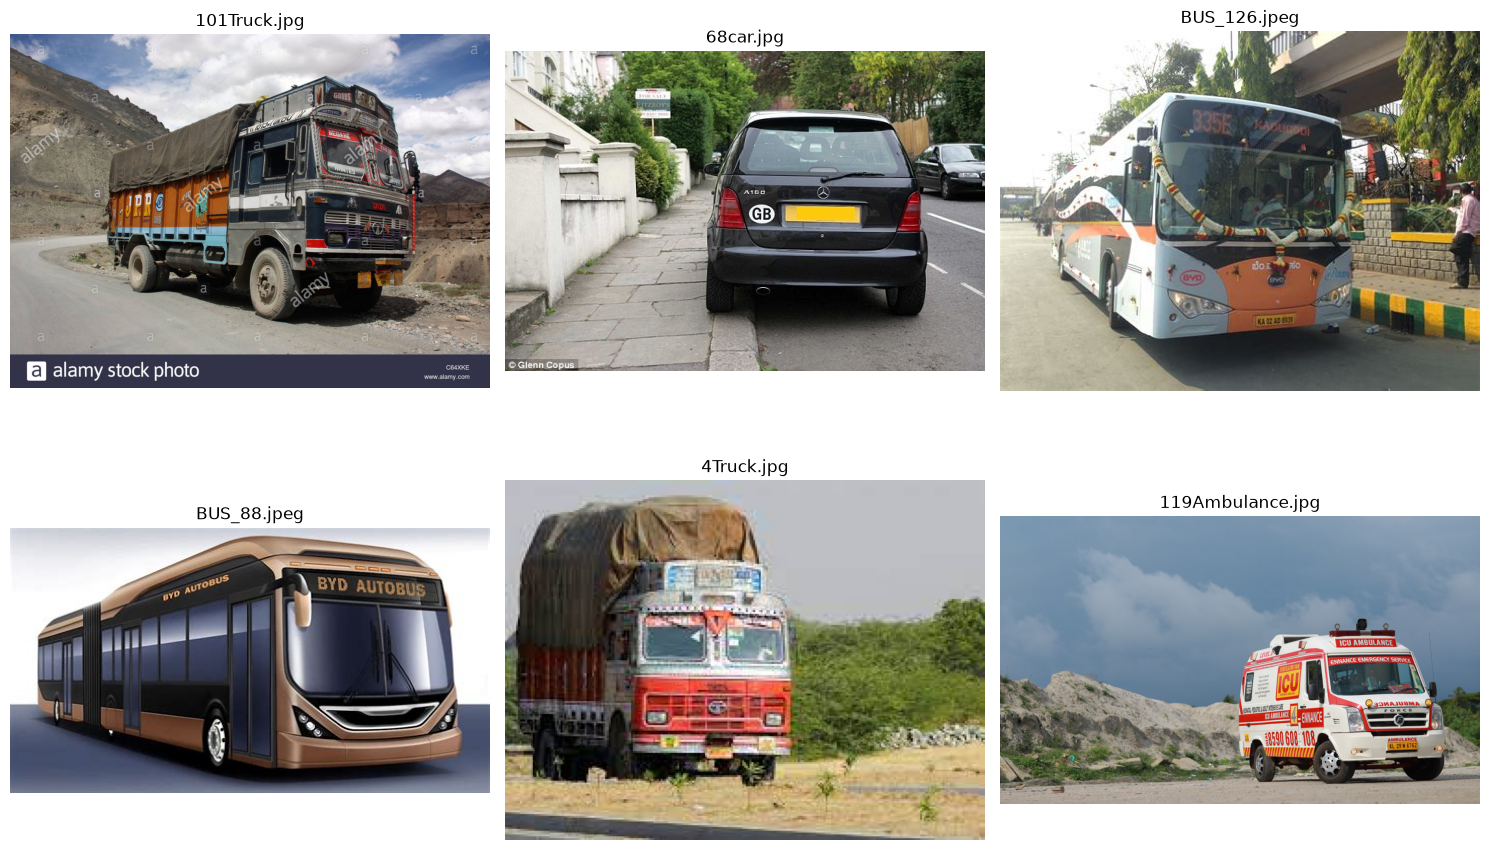

In [30]:
sample_images = random.sample(train_images, min(6, len(train_images)))

plt.figure(figsize=(15, 10))

for i, img_path in enumerate(sample_images):
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(img_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

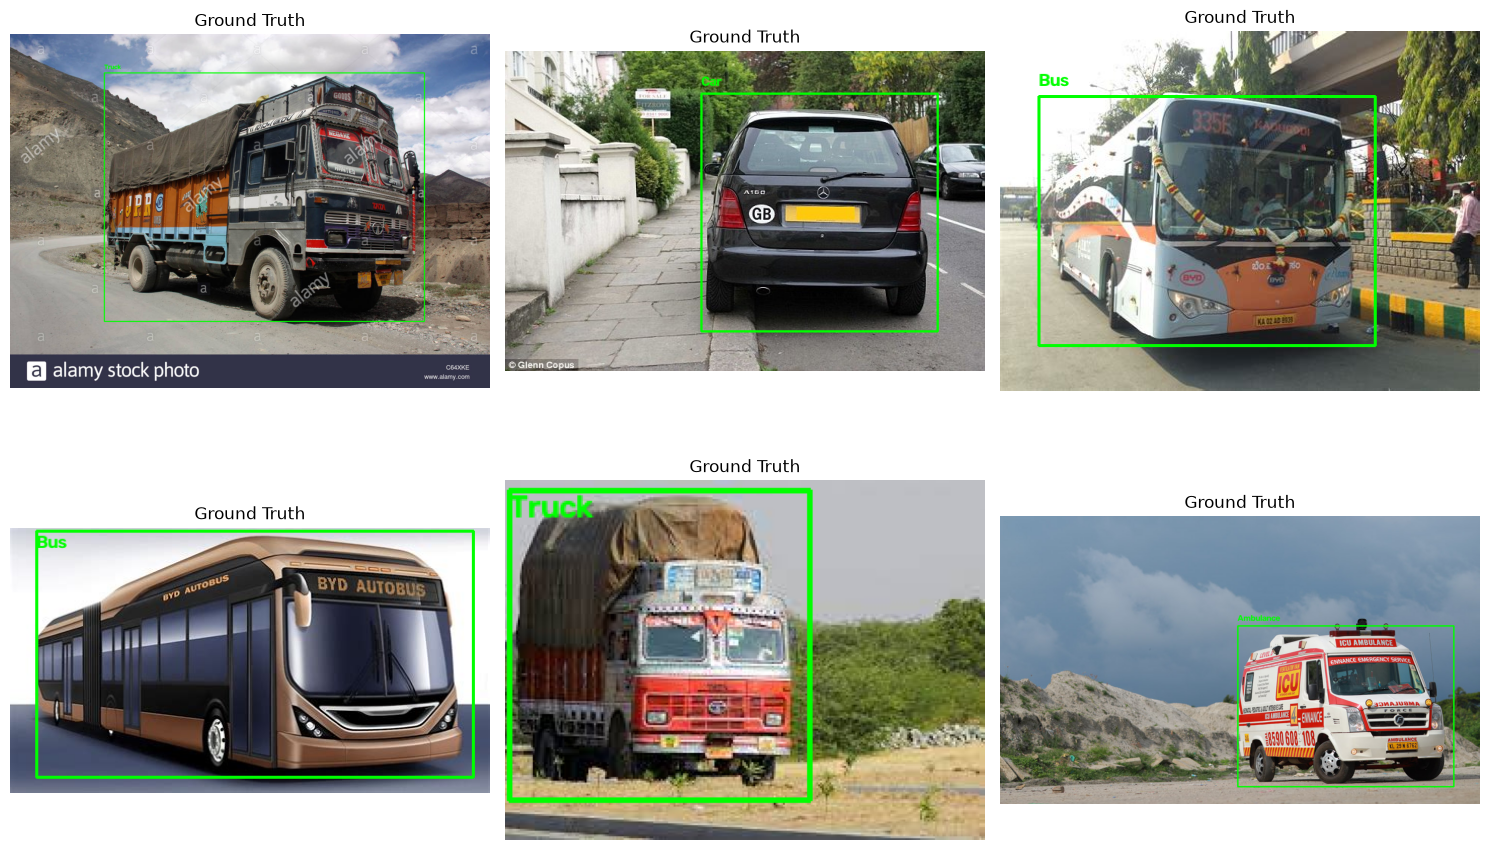

In [31]:
def draw_yolo_labels(image_path, label_path):
    
    image = cv2.imread(str(image_path))
    
    h, w = image.shape[:2]
    
    with open(label_path, "r") as f:
        lines = f.readlines()
    
    for line in lines:
        parts = line.strip().split()
        
        if len(parts) != 5:
            continue
        
        class_id = int(float(parts[0]))
        x_center, y_center, box_w, box_h = map(float, parts[1:])
        
        x_center *= w
        y_center *= h
        box_w *= w
        box_h *= h
        
        x1 = int(x_center - box_w / 2)
        y1 = int(y_center - box_h / 2)
        x2 = int(x_center + box_w / 2)
        y2 = int(y_center + box_h / 2)
        
        label = CLASS_NAMES[class_id]
        
        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )
        
        cv2.putText(
            image,
            label,
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )
    
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(15, 10))

for i, img_path in enumerate(sample_images):
    
    label_path = label_map[img_path.stem]
    
    image = draw_yolo_labels(img_path, label_path)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title("Ground Truth")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
import torch

if torch.cuda.is_available():
    print("GPU available!")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available.")
    print("Training will use CPU.")

GPU not available.
Training will use CPU.


In [33]:
model = YOLO("yolov8n.pt")

print("YOLOv8 model loaded successfully.")

YOLOv8 model loaded successfully.


In [34]:
import torch

device = 0 if torch.cuda.is_available() else "cpu"

if torch.cuda.is_available():
    batch_size = 16
else:
    batch_size = 4

print("Training device:", device)
print("Batch size:", batch_size)

results = model.train(
    data=str(yaml_path),
    epochs=9,
    imgsz=640,
    batch=batch_size,
    device=device,
    workers=0,
    patience=8,
    project=str(PROJECT_DIR / "runs"),
    name="vehicle_detection_yolov8",
    pretrained=True,
    verbose=True
)

Training device: cpu
Batch size: 4
Ultralytics 8.4.124  Python-3.12.7 torch-2.13.0+cpu CPU (12th Gen Intel Core i5-1235U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Advanced data science Lab\Assignment_4\yolo_dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=9, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum

In [35]:
BEST_MODEL = PROJECT_DIR / "runs" / "vehicle_detection_yolov8" / "weights" / "best.pt"

print("Best model path:")
print(BEST_MODEL)

print("\nExists:", BEST_MODEL.exists())

Best model path:
D:\Advanced data science Lab\Assignment_4\runs\vehicle_detection_yolov8\weights\best.pt

Exists: True


In [36]:
trained_model = YOLO(str(BEST_MODEL))

print("Trained YOLOv8 model loaded.")

Trained YOLOv8 model loaded.


In [37]:
metrics = trained_model.val(
    data=str(yaml_path),
    imgsz=640,
    batch=batch_size,
    device=device
)

print("Validation completed.")

Ultralytics 8.4.124  Python-3.12.7 torch-2.13.0+cpu CPU (12th Gen Intel Core i5-1235U)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 323.6248.4 MB/s, size: 96.2 KB)
val: Scanning D:\Advanced data science Lab\Assignment_4\yolo_dataset\labels\val.cache... 112 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 112/112  0.0s
val: D:\Advanced data science Lab\Assignment_4\yolo_dataset\images\val\16car.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.4it/s 11.9s0.5s
                   all        112        114        0.8      0.763       0.89      0.682
             Ambulance         25         25       0.93      0.535      0.941      0.789
                   Bus         28         28      0.883      0.811      0.886      0.695
                   Car         34         37      0.785      0.788      0.866    

In [38]:
print("========== MODEL PERFORMANCE ==========")

print(f"Precision : {metrics.box.mp:.4f}")
print(f"Recall    : {metrics.box.mr:.4f}")
print(f"mAP@0.50  : {metrics.box.map50:.4f}")
print(f"mAP@0.50:0.95 : {metrics.box.map:.4f}")

print("======================================")

========== MODEL PERFORMANCE ==========
Precision : 0.8004
Recall    : 0.7625
mAP@0.50  : 0.8905
mAP@0.50:0.95 : 0.6821


In [39]:
results_dir = PROJECT_DIR / "runs" / "vehicle_detection_yolov8"

print("Training results directory:")
print(results_dir)

print("\nFiles generated:")

for file in results_dir.iterdir():
    print(file.name)

Training results directory:
D:\Advanced data science Lab\Assignment_4\runs\vehicle_detection_yolov8

Files generated:
args.yaml
labels.jpg
results.csv
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
weights


In [40]:
results_image = results_dir / "results.png"

if results_image.exists():
    img = cv2.imread(str(results_image))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(16, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print("results.png not found.")

results.png not found.


In [41]:
confusion_matrix_path = results_dir / "confusion_matrix.png"

if confusion_matrix_path.exists():
    img = cv2.imread(str(confusion_matrix_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print("Confusion matrix not found.")

Confusion matrix not found.


In [42]:
confusion_matrix_path = results_dir / "confusion_matrix.png"

if confusion_matrix_path.exists():
    img = cv2.imread(str(confusion_matrix_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print("Confusion matrix not found.")

Confusion matrix not found.


In [43]:
test_image = random.choice(val_images)

print("Testing image:")
print(test_image)

prediction = trained_model.predict(
    source=str(test_image),
    conf=0.40,
    imgsz=640,
    save=True
)

Testing image:
D:\Advanced data science Lab\Assignment_4\archive (6)\training_image\BUS_135.jpeg

image 1/1 D:\Advanced data science Lab\Assignment_4\archive (6)\training_image\BUS_135.jpeg: 416x640 1 Bus, 129.4ms
Speed: 2.0ms preprocess, 129.4ms inference, 6.1ms postprocess per image at shape (1, 3, 416, 640)
Results saved to D:\Advanced data science Lab\runs\detect\predict


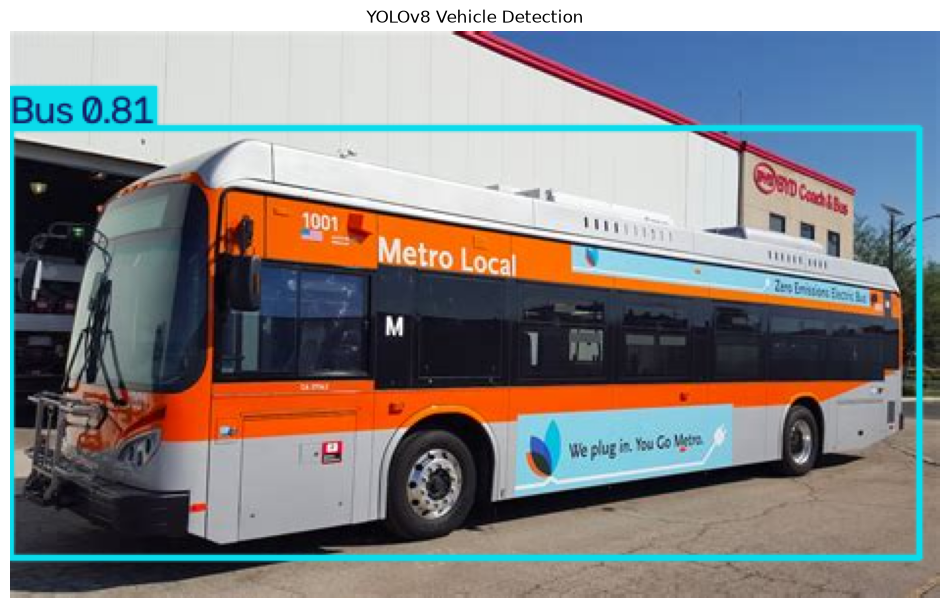

In [44]:
result = prediction[0]

annotated_image = result.plot()

annotated_image = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_image)
plt.axis("off")
plt.title("YOLOv8 Vehicle Detection")
plt.show()

In [45]:
result = prediction[0]

detected_classes = []

for box in result.boxes:
    class_id = int(box.cls[0])
    class_name = trained_model.names[class_id]
    confidence = float(box.conf[0])

    detected_classes.append(class_name)

print("Detected objects:")
for cls in detected_classes:
    print("-", cls)

print("\nTotal detected objects:", len(detected_classes))

Detected objects:
- Bus

Total detected objects: 1


In [46]:
class_counts = Counter(detected_classes)

print("========== VEHICLE COUNT ==========")

for class_name in CLASS_NAMES:
    print(
        f"{class_name}: "
        f"{class_counts.get(class_name, 0)}"
    )

print(
    "Total:",
    sum(class_counts.values())
)

print("===================================")

========== VEHICLE COUNT ==========
Ambulance: 0
Bus: 1
Car: 0
Truck: 0
Total: 1


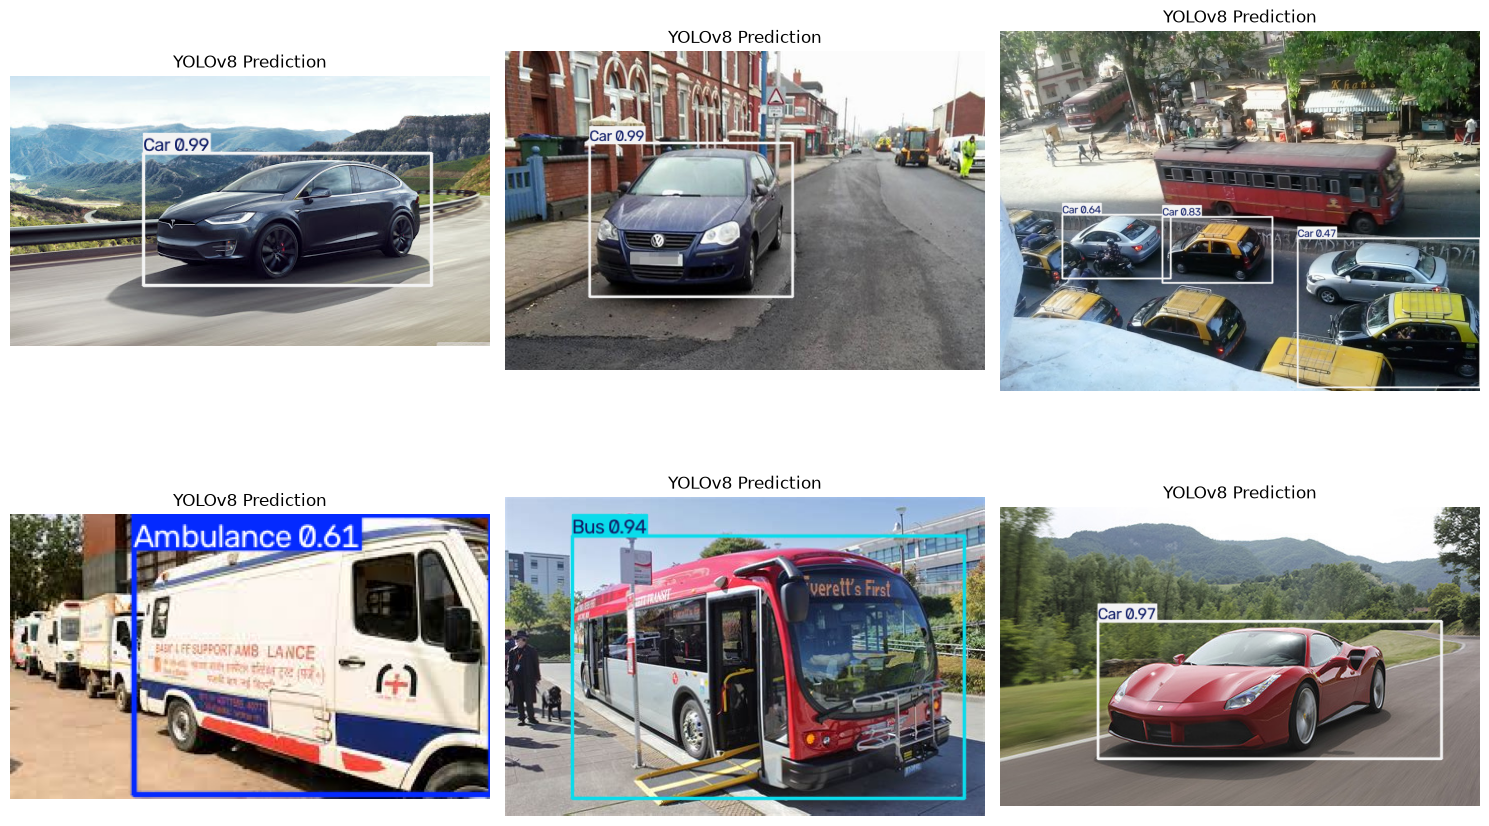

In [49]:
sample_test_images = random.sample(
    val_images,
    min(6, len(val_images))
)

plt.figure(figsize=(15, 10))

for i, img_path in enumerate(sample_test_images):

    result = trained_model.predict(
        source=str(img_path),
        conf=0.40,
        imgsz=640,
        verbose=False
    )[0]

    annotated = result.plot()
    annotated = cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2, 3, i + 1)
    plt.imshow(annotated)
    plt.title("YOLOv8 Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()